# Final Notebook  

#### By Emily Cadena 

## Who’s Most at Risk? Social Demographics and Traffic Collisions in the City of Los Angeles

### This notebook will examine the Top 15 census tracts that has the most collisions per 1,000 people and examine who is most impacted. 

### Data Sources & Geographic Information

American Community Survey (ACS) 2015-2019 (5-Year Estimates) - Hispanic or Latino by Race  
2015 - 2019 UC Berkeley  
TIMS  2019 Census Tracts from IPUMS NHGIS  


### Importing libraries 

In [36]:
# data exploration 
import pandas as pd

# merge data 
import geopandas as gpd

# basemaps
import contextily as ctx

# spatial statistics
import esda
from esda.moran import Moran, Moran_Local

import splot
from splot.esda import moran_scatterplot, plot_moran, lisa_cluster,plot_moran_simulation

import libpysal as lps  

# importing for plots and tables 
import matplotlib.pyplot as plt
import plotly.express as px

In [37]:
# upload acs 2015-2019 for data exploration
race = pd.read_csv('data10/race15_19.csv')

### Converting Data Types

In [38]:
# going into the Geo_FIPS column
# leading zero is missing 
race.Geo_FIPS.head()

0    6037101110
1    6037101122
2    6037101210
3    6037101220
4    6037101300
Name: Geo_FIPS, dtype: int64

In [39]:
# converting FIPS, state, and county data type from integer to string to include leading zero 
race = pd.read_csv('data10/race15_19.csv',
     dtype=
                 {'Geo_FIPS': str, 
                  'Geo_STATE': str, 
                  'Geo_COUNTY': str })

### Cleaning and Reorganizing the data

In [40]:
# find unnecessary columns with zero values 
race.columns[race.isna().all()].tolist()

['Geo_US',
 'Geo_REGION',
 'Geo_DIVISION',
 'Geo_STATECE',
 'Geo_COUSUB',
 'Geo_PLACE',
 'Geo_PLACESE',
 'Geo_PUMA1']

In [41]:
# deleting uncessary columns 
race = race.dropna(axis=1,how="all")

In [42]:
# keep columns
columns_to_keep = ['Geo_FIPS', 
                   'Geo_STATE', 
                   'Geo_COUNTY',
                   'Geo_TRACT',
                   'SE_B04001_001', 
                   'SE_B04001_002', 
                   'SE_B04001_003',      
                   'SE_B04001_004',       
                   'SE_B04001_005',        
                   'SE_B04001_006',       
                   'SE_B04001_007',        
                   'SE_B04001_008',       
                   'SE_B04001_009',      
                   'SE_B04001_010',      
                   'PCT_SE_B04001_002',  
                   'PCT_SE_B04001_003',
                   'PCT_SE_B04001_004',  
                   'PCT_SE_B04001_005',  
                   'PCT_SE_B04001_006',  
                   'PCT_SE_B04001_007',  
                   'PCT_SE_B04001_008',  
                   'PCT_SE_B04001_009',  
                   'PCT_SE_B04001_010']

race=race[columns_to_keep]

In [43]:
race.columns.to_list()

['Geo_FIPS',
 'Geo_STATE',
 'Geo_COUNTY',
 'Geo_TRACT',
 'SE_B04001_001',
 'SE_B04001_002',
 'SE_B04001_003',
 'SE_B04001_004',
 'SE_B04001_005',
 'SE_B04001_006',
 'SE_B04001_007',
 'SE_B04001_008',
 'SE_B04001_009',
 'SE_B04001_010',
 'PCT_SE_B04001_002',
 'PCT_SE_B04001_003',
 'PCT_SE_B04001_004',
 'PCT_SE_B04001_005',
 'PCT_SE_B04001_006',
 'PCT_SE_B04001_007',
 'PCT_SE_B04001_008',
 'PCT_SE_B04001_009',
 'PCT_SE_B04001_010']

In [44]:
# rename columns
# % is total population XXX (ex. % Total Population: Hispanic or Latino)
race.columns = ['FIPS',
                'State',
                'County',
                'Census Tract',
                'Total Population',
                'Total Population: Not Hispanic or Latino',
                'White',
                'Black',
                'American Indian and Alaska Native Alone',
                'Asian',
                'Native Hawaiian and Other Pacific Islander Alone',
                'Some Other Race Alone',
                'Two or More Races',
                'Hispanic or Latino',
                '% Not Hispanic or Latino',
                '% White',
                '% Black',
                '% American Indian and Alaska Native Alone',
                '% Asian',
                '% Native Hawaiian and Other Pacific Islander Alone',
                '% Some Other Race Alone',
                '% Two or More Races',
                '% Hispanic or Latino']

In [45]:
race.head(2)

,FIPS,State,County,Census Tract,Total Population,Total Population: Not Hispanic or Latino,White,Black,American Indian and Alaska Native Alone,Asian,...,Hispanic or Latino,% Not Hispanic or Latino,% White,% Black,% American Indian and Alaska Native Alone,% Asian,% Native Hawaiian and Other Pacific Islander Alone,% Some Other Race Alone,% Two or More Races,% Hispanic or Latino
0,06037101110,06,037,101110,4283,3095,2616,19,3,331,...,1188,72.26,61.08,0.44,0.07,7.73,0.07,0.19,2.69,27.74
1,06037101122,06,037,101122,3405,3258,2882,74,15,220,...,147,95.68,84.64,2.17,0.44,6.46,0.00,0.00,1.97,4.32


### Creating POC Column

In [46]:
#creating a new column PCT_POC - Includes % Black, % Asian, and % Hispanic and latino
race['PCT_POCv1'] = race['% Black'] + race['% Asian']+ race['% Hispanic or Latino']

In [47]:
# double checking PCT_POC column by creating a second column 
race['PCT_POCv2'] = None

In [48]:
race['PCT_POCv2'] = race['Black'] + race['Asian']+ race['Hispanic or Latino']

In [49]:
race['PCT_POCv2'] = race['PCT_POCv2']/race['Total Population']*100

In [50]:
#rename a column 
race.rename(columns={'PCT_POCv1': '% People of Color'}, inplace=True)

In [51]:
race.head(2)
# have practically the same result for PCT_POCv1 and PCT_POCv2 

,FIPS,State,County,Census Tract,Total Population,Total Population: Not Hispanic or Latino,White,Black,American Indian and Alaska Native Alone,Asian,...,% White,% Black,% American Indian and Alaska Native Alone,% Asian,% Native Hawaiian and Other Pacific Islander Alone,% Some Other Race Alone,% Two or More Races,% Hispanic or Latino,% People of Color,PCT_POCv2
0,06037101110,06,037,101110,4283,3095,2616,19,3,331,...,61.08,0.44,0.07,7.73,0.07,0.19,2.69,27.74,35.91,35.909409
1,06037101122,06,037,101122,3405,3258,2882,74,15,220,...,84.64,2.17,0.44,6.46,0.00,0.00,1.97,4.32,12.95,12.951542


### Merge

In [52]:
# add city of LA census tract 
cityofla=gpd.read_file('data10/cityLA.zip')

In [53]:
# add a FIPS column
# creating a new column so that I can merge the shapefile and census tracts 

cityofla['FIPS'] = '06' + '037' + cityofla['TRACTCE']

In [54]:
# need to merge by creating a new dataframe
la_race =cityofla.merge(race,on="FIPS")

In [55]:
# find the sum for each race and ethncity 
print(la_race['White'].sum())
print(la_race['Black'].sum())
print(la_race['Asian'].sum())
print(la_race['Hispanic or Latino'].sum())

1378808
430875
543767
2220293


In [56]:
#racebar1 only includes data for reach race and ethnicity in the City of LA  

racebar1 = racebar1=pd.DataFrame({'Race and Ethnicity':['White', 'Black', 'Asian', 'Hispanic or Latino'], 
                   'Population Count':[1378808, 430875, 543767, 2220293], 
                   'Color':['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']}) 

In [57]:
# creating a bar chart of race and ethnicty in LA County using plotly 
fig = px.bar(racebar1, 
       x='Race and Ethnicity',
       y='Population Count',
       title='Race & Ethnicity in the City of Los Angeles, 2019',
       color='Race and Ethnicity', 
       color_discrete_sequence=racebar1['Color'])
    
# get rid of white lines inside the bars
fig.update_traces(marker_line_width=0)

fig.update_layout(xaxis_tickangle=0, 
                  plot_bgcolor='rgba(0,0,0,0)',
                  paper_bgcolor='rgba(0,0,0,0)'
                 )
 
# show the figure
fig.show()

### Function and loop for Race & Ethnicity

In [58]:
# Created a function here because eventually, I want to loop through VARIOUS columns instead of unique values within ONE Column 

def plot_maps(data, columns, title_prefix):  

     for column in columns:
        fig, ax = plt.subplots(figsize=(12, 12))
        la_race.plot(ax=ax,column=column,legend=True,cmap='GnBu',
             legend_kwds={"label": "Population (%)", "orientation": "vertical"})
      
        ax.axis('off')
        ax.set_title (f" {column} {title_prefix}")

        ax.set_aspect('equal')

        filename = f"{save_prefix}_{column}.png"
        plt.savefig(filename)
        plt.close()

In [59]:
#columns to plot 
race_map = ['% White', '% Black', '% Asian', '% Hispanic or Latino', '% People of Color', 'PCT_POCv2']
save_prefix = "population_los_angeles_2019"


In [60]:
# loop!
plot_maps(la_race, race_map, "Population in the City of Los Angeles, 2019")


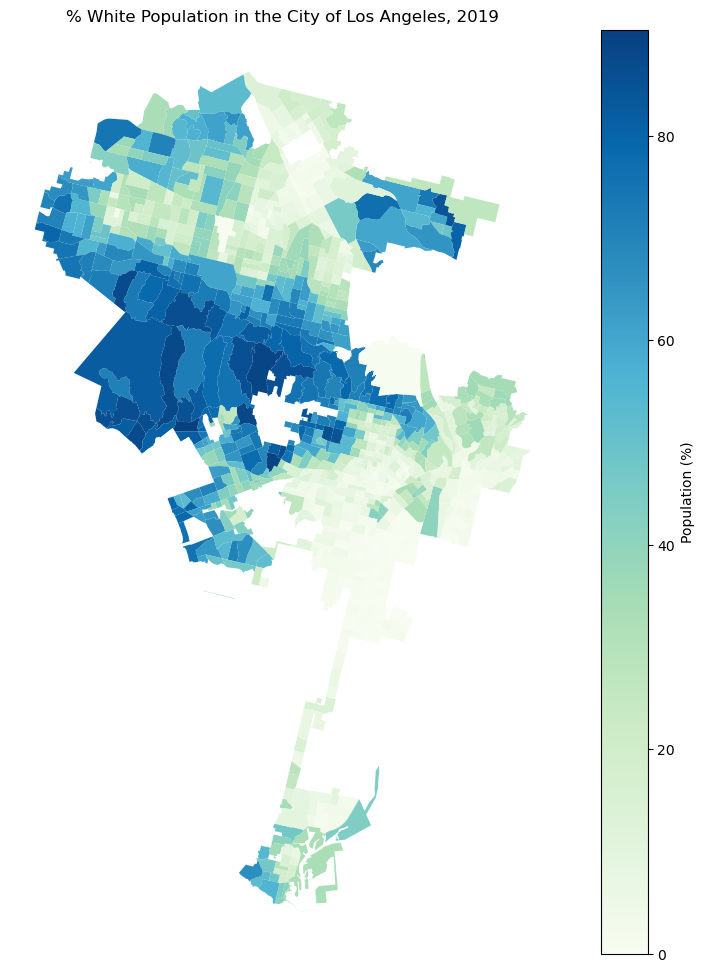

In [61]:
fig,ax = plt.subplots(figsize=(12,12))

la_race.plot(ax=ax,column='% White',legend=True,cmap='GnBu',
             legend_kwds={"label": "Population (%)", "orientation": "vertical"})

ax.axis('off')
ax.set_title('% White Population in the City of Los Angeles, 2019')
ax.set_aspect('equal')

plt.savefig('data10/white.jpg')

In [65]:
la_race.sample(2)

,GISJOIN,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,% White,% Black,% American Indian and Alaska Native Alone,% Asian,% Native Hawaiian and Other Pacific Islander Alone,% Some Other Race Alone,% Two or More Races,% Hispanic or Latino,% People of Color,PCT_POCv2
454,G0600370192700,06,037,192700,06037192700,1927,Census Tract 1927,G5020,S,531205.0,...,11.92,1.91,0.0,18.44,0.0,0.00,5.51,62.22,82.57,82.574659
465,G0600370195300,06,037,195300,06037195300,1953,Census Tract 1953,G5020,S,580349.0,...,56.20,1.55,0.0,9.55,0.0,0.45,1.91,30.33,41.43,41.437358


In [69]:
#save the top 15 census tracts with most collisions per 1,000
top15 = ['06037226002', '06037980024', '06037207400', '06037224020', '06037207710', '06037224010', '06037226001',
         '06037206200', '06037190700', '06037273402', '06037203300', '06037203300',	 '06037208801', '06037207102', '06037296600']

In [70]:
top15ct = la_race[la_race['GEOID'].isin(top15)]

In [71]:
print(top15ct)

             GISJOIN STATEFP COUNTYFP TRACTCE        GEOID     NAME  \
421   G0600370190700      06      037  190700  06037190700     1907   
509   G0600370203300      06      037  203300  06037203300     2033   
535   G0600370206200      06      037  206200  06037206200     2062   
538   G0600370207102      06      037  207102  06037207102  2071.02   
542   G0600370207400      06      037  207400  06037207400     2074   
545   G0600370207710      06      037  207710  06037207710  2077.10   
558   G0600370208801      06      037  208801  06037208801  2088.01   
692   G0600370224010      06      037  224010  06037224010  2240.10   
693   G0600370224020      06      037  224020  06037224020  2240.20   
701   G0600370226001      06      037  226001  06037226001  2260.01   
702   G0600370226002      06      037  226002  06037226002  2260.02   
907   G0600370273402      06      037  273402  06037273402  2734.02   
974   G0600370296600      06      037  296600  06037296600     2966   
1162  

In [73]:
top15ct.describe()

,ALAND,AWATER,Shape_Leng,Shape_Le_1,Shape_Area,Census Tract,Total Population,Total Population: Not Hispanic or Latino,White,Black,...,% White,% Black,% American Indian and Alaska Native Alone,% Asian,% Native Hawaiian and Other Pacific Islander Alone,% Some Other Race Alone,% Two or More Races,% Hispanic or Latino,% People of Color,PCT_POCv2
count,1.400000e+01,14.00000,14.000000,14.000000,1.400000e+01,14.000000,14.000000,14.000000,14.000000,14.000000,...,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000
mean,1.460932e+06,51348.00000,4994.746680,4993.659713,1.484411e+06,277233.714286,2791.428571,1512.000000,631.928571,302.857143,...,25.257143,11.115000,0.491429,15.305714,0.040714,0.112857,2.215714,45.462143,71.882857,71.883394
std,1.965517e+06,123176.80833,2831.931166,2832.547283,2.037753e+06,204286.698629,1284.479105,1152.995563,648.191860,199.236951,...,24.200446,6.290454,0.919915,18.386571,0.104400,0.195622,2.308079,27.208999,24.853576,24.853706
min,2.342450e+05,0.00000,2381.409192,2381.409192,2.684556e+05,190700.000000,223.000000,169.000000,10.000000,16.000000,...,0.380000,2.740000,0.000000,0.000000,0.000000,0.000000,0.000000,13.780000,19.910000,19.916698
25%,6.276468e+05,0.00000,3610.880553,3610.880553,6.253524e+05,207176.500000,2153.750000,579.750000,184.000000,169.750000,...,9.640000,6.247500,0.000000,2.845000,0.000000,0.000000,0.815000,22.575000,62.512500,62.508341
50%,8.524520e+05,0.00000,4428.324952,4428.324952,8.556800e+05,216405.500000,2709.000000,1259.500000,395.500000,251.000000,...,14.920000,9.885000,0.080000,7.595000,0.000000,0.000000,1.480000,44.105000,82.840000,82.839437
75%,1.199557e+06,5556.50000,5122.396883,5122.396883,1.199559e+06,226001.750000,3001.750000,2214.500000,748.500000,404.250000,...,34.367500,14.697500,0.330000,19.382500,0.000000,0.210000,3.105000,71.020000,87.337500,87.333644
max,7.998841e+06,387101.00000,14070.622908,14070.622908,8.287090e+06,980024.000000,5358.000000,4016.000000,2087.000000,734.000000,...,79.020000,25.730000,2.690000,57.930000,0.320000,0.580000,8.790000,88.360000,99.270000,99.273423
